In [8]:
%pip install matplotlib torch torchvision requests

Note: you may need to restart the kernel to use updated packages.


# Style Transfer with Deep Neural Networks


In this notebook, we’ll *recreate* a style transfer method that is outlined in the paper, [Image Style Transfer Using Convolutional Neural Networks, by Gatys](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf) in PyTorch.

In this notebook, we'll use a pre-trained VGG19 Net to extract content or style features from a passed in image. We'll then formalize the idea of content and style _losses_ and use those to iteratively update our target image until we get a result that we want. You are encouraged to use a style and content image of your own.

In [9]:
# import resources
%matplotlib inline

from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.optim as optim
import requests
from torchvision import transforms, models

## Load in VGG19 (features)

VGG19 is split into two portions:
* `vgg19.features`, which are all the convolutional and pooling layers
* `vgg19.classifier`, which are the three linear, classifier layers at the end

We only need the `features` portion, which we're going to load in and "freeze" the weights of, below.

In [10]:
# get the "features" portion of VGG19 (we will not need the "classifier" portion)
vgg = models.vgg19(pretrained=True).features

# freeze all VGG parameters since we're only optimizing the target image
for param in vgg.parameters():
    param.requires_grad_(False)

c:\Users\tyler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\tyler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\tyler/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100.0%


In [11]:
# move the model to GPU, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

### Load in Content and Style Images

You can load in any images you want! Below, we've provided a helper function for loading in any type and size of image. The `load_image` function also converts images to normalized Tensors.

Additionally, it will be easier to have smaller images and to squish the content and style images so that they are of the same size.

In [12]:
def load_image(img_path, max_size=400, shape=None):
    ''' Load in and transform an image, making sure the image
       is <= 400 pixels in the x-y dims.'''
    if "http" in img_path:
        response = requests.get(img_path)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(img_path).convert('RGB')
    
    # large images will slow down processing
    if max(image.size) > max_size:
        size = max_size
    else:
        size = max(image.size)
    
    if shape is not None:
        size = shape
        
    in_transform = transforms.Compose([
                        transforms.Resize(size),
                        transforms.ToTensor(),
                        transforms.Normalize((0.485, 0.456, 0.406), 
                                             (0.229, 0.224, 0.225))])

    # discard the transparent, alpha channel (that's the :3) and add the batch dimension
    image = in_transform(image)[:3,:,:].unsqueeze(0)
    
    return image

Next, I'm loading in images by file name and forcing the style image to be the same size as the content image.

**TODO**: use your content vs style images.

In [27]:
import os

# Prefer local real images for assignment results.
content_path = 'image_filtering/building2.jpg'
style_path = 'build_cnn/cifar_data.png'

# Fallback generation only if local images are unavailable.
if not (os.path.exists(content_path) and os.path.exists(style_path)):
    os.makedirs('images', exist_ok=True)
    if not os.path.exists('images/content.jpg'):
        h, w = 400, 600
        x = np.linspace(0, 1, w, dtype=np.float32)
        y = np.linspace(0, 1, h, dtype=np.float32)
        xx, yy = np.meshgrid(x, y)
        content_arr = np.stack([xx, yy, 0.5 * np.ones_like(xx)], axis=-1)
        Image.fromarray((content_arr * 255).astype(np.uint8)).save('images/content.jpg')

    if not os.path.exists('images/style.jpg'):
        h, w = 400, 600
        stripes = (np.sin(np.linspace(0, 40, w))[None, :] + 1) / 2
        stripes = np.repeat(stripes, h, axis=0)
        style_arr = np.stack([0.2 + 0.8 * stripes, 0.1 + 0.3 * (1 - stripes), 0.8 * (1 - stripes)], axis=-1)
        Image.fromarray((style_arr * 255).astype(np.uint8)).save('images/style.jpg')
    content_path = 'images/content.jpg'
    style_path = 'images/style.jpg'

# load in content and style image
content = load_image(content_path).to(device)
# Resize style to match content, makes code easier
style = load_image(style_path, shape=content.shape[-2:]).to(device)

print(f'Using content image: {content_path}')
print(f'Using style image: {style_path}')

Using content image: image_filtering/building2.jpg
Using style image: build_cnn/cifar_data.png


In [17]:
# helper function for un-normalizing an image 
# and converting it from a Tensor image to a NumPy image for display
def im_convert(tensor):
    """ Display a tensor as an image. """
    
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)

    return image

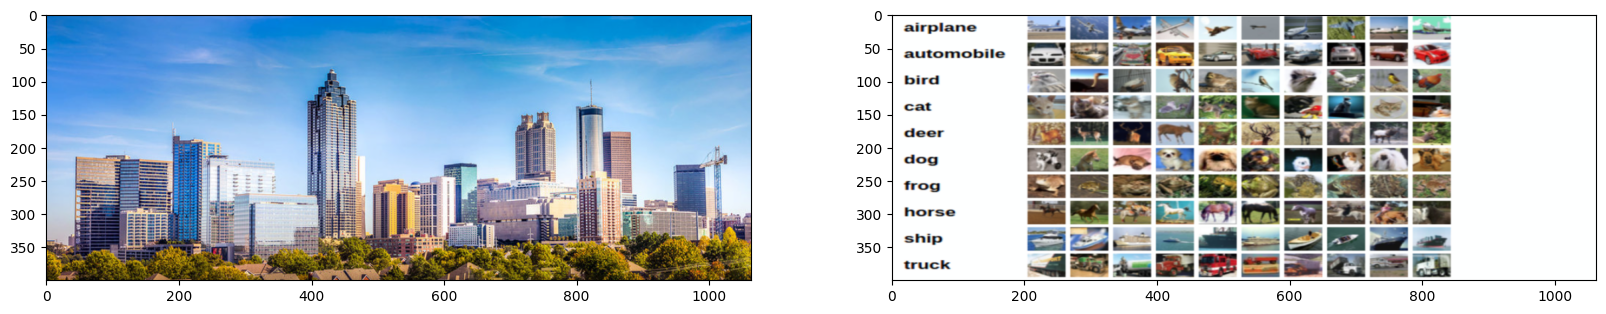

In [28]:
# display the images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
# content and style ims side-by-side
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(style))

---
## VGG19 Layers

To get the content and style representations of an image, we have to pass an image forward through the VGG19 network until we get to the desired layer(s) and then get the output from that layer.

In [ ]:
# print out VGG19 structure so you can see the names of various layers
# print(vgg)

## Content and Style Features

#### **TODO**: complete the mapping of layer names to the names found in the paper for the _content representation_ and the _style representation_.

The first layer (0) to `conv1_1` has been done for you, below.

In [22]:
def get_features(image, model, layers=None):
    """ Run an image forward through a model and get the features for 
        a set of layers. Default layers are for VGGNet matching Gatys et al (2016)
    """
    
    ## TODO: Complete mapping layer names of PyTorch's VGGNet to names from the paper
    ## Need the layers for the content and style representations of an image
    if layers is None:
        layers = {
        '0': 'conv1_1',
        '5': 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '21': 'conv4_2',
        '28': 'conv5_1'
    }
        
        
    ## -- do not need to change the code below this line -- ##
    features = {}
    x = image
    # model._modules is a dictionary holding each module in the model
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
            
    return features

---
## Gram Matrix 

The output of every convolutional layer is a Tensor with dimensions associated with the `batch_size`, a depth, `d` and some height and width (`h`, `w`). The Gram matrix of a convolutional layer can be calculated as follows:
* Get the depth, height, and width of a tensor using `batch_size, d, h, w = tensor.size()`
* Reshape that tensor so that the spatial dimensions are flattened
* Calculate the gram matrix by multiplying the reshaped tensor by it's transpose 

*Note: You can multiply two matrices using `torch.mm(matrix1, matrix2)`.*

#### TODO: Complete the `gram_matrix` function.

In [23]:
def gram_matrix(tensor):
    batch_size, d, h, w = tensor.size()
    features = tensor.view(d, h*w)
    gram = torch.mm(features, features.t())
    return gram

## Putting it all Together

Now that we've written functions for extracting features and computing the gram matrix of a given convolutional layer; let's put all these pieces together! We'll extract our features from our images and calculate the gram matrices for each layer in our style representation.

In [29]:
# get content and style features only once before forming the target image
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

# calculate the gram matrices for each layer of our style representation
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# create a third "target" image and prep it for change
# it is a good idea to start off with the target as a copy of our *content* image
# then iteratively change its style
target = content.clone().requires_grad_(True).to(device)

---
## Loss and Weights

#### Individual Layer Style Weights

Below, you are given the option to weight the style representation at each relevant layer. It's suggested that you use a range between 0-1 to weight these layers. By weighting earlier layers (`conv1_1` and `conv2_1`) more, you can expect to get _larger_ style artifacts in your resulting, target image. Should you choose to weight later layers, you'll get more emphasis on smaller features. This is because each layer is a different size and together they create a multi-scale style representation!

#### Content and Style Weight

Just like in the paper, we define an alpha (`content_weight`) and a beta (`style_weight`). This ratio will affect how _stylized_ your final image is. It's recommended that you leave the content_weight = 1 and set the style_weight to achieve the ratio you want.

In [30]:
# weights for each style layer 
# weighting earlier layers more will result in *larger* style artifacts
# notice we are excluding `conv4_2` our content representation
style_weights = {'conv1_1': 1.,
                 'conv2_1': 0.8,
                 'conv3_1': 0.5,
                 'conv4_1': 0.3,
                 'conv5_1': 0.1}

# you may choose to leave these as is
content_weight = 1  # alpha
style_weight = 1e6  # beta

## Updating the Target & Calculating Losses

You'll decide on a number of steps for which to update your image, this is similar to the training loop that you've seen before, only we are changing our _target_ image and nothing else about VGG19 or any other image. Therefore, the number of steps is really up to you to set! **I recommend using at least 2000 steps for good results.** But, you may want to start out with fewer steps if you are just testing out different weight values or experimenting with different images.

Inside the iteration loop, you'll calculate the content and style losses and update your target image, accordingly.

#### Content Loss

The content loss will be the mean squared difference between the target and content features at layer `conv4_2`. This can be calculated as follows: 
```
content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)
```

#### Style Loss

The style loss is calculated in a similar way, only you have to iterate through a number of layers, specified by name in our dictionary `style_weights`. 
> You'll calculate the gram matrix for the target image, `target_gram` and style image `style_gram` at each of these layers and compare those gram matrices, calculating the `layer_style_loss`. 
> Later, you'll see that this value is normalized by the size of the layer.

#### Total Loss

Finally, you'll create the total loss by adding up the style and content losses and weighting them with your specified alpha and beta!

Intermittently, we'll print out this loss; don't be alarmed if the loss is very large. It takes some time for an image's style to change and you should focus on the appearance of your target image rather than any loss value. Still, you should see that this loss decreases over some number of iterations.

#### TODO: Define content, style, and total losses.

In [ ]:
# for displaying the target image, intermittently
import time

show_every = 400

# iteration hyperparameters
optimizer = optim.Adam([target], lr=0.003)
steps = 2000  # decide how many iterations to update your image (5000)

loss_history = []
start_time = time.time()

for ii in range(1, steps+1):
    
    # get the features from your target image    
    # Then calculate the content loss
    target_features = get_features(target, vgg)
    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)
    
    # the style loss
    # initialize the style loss to 0
    style_loss = 0
    # iterate through each style layer and add to the style loss
    for layer in style_weights:
        # get the "target" style representation for the layer
        target_feature = target_features[layer]
        _, d, h, w = target_feature.shape
        
        # Calculate the target gram matrix
        target_gram = gram_matrix(target_feature)
        
        # get the "style" style representation
        style_gram = style_grams[layer]
        # Calculate the style loss for one layer, weighted appropriately
        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram)**2)
        
        # add to the style loss
        style_loss += layer_style_loss / (d * h * w)
        
    # calculate the *total* loss
    total_loss = content_weight * content_loss + style_weight * style_loss
    
    # -- do not need to change code, below -- #
    # update your target image
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # display intermediate images and print the loss
    if ii % show_every == 0:
        current_loss = float(total_loss.item())
        loss_history.append((ii, current_loss))
        print('Total loss: ', current_loss)
        plt.imshow(im_convert(target))
        plt.show()

# Save final run metrics for experiment logging/reporting.
final_total_loss = float(total_loss.item())
elapsed_seconds = time.time() - start_time
print(f'Final total loss: {final_total_loss:.4f} | elapsed: {elapsed_seconds:.1f}s')

## Display the Target Image

In [ ]:
# display content and final, target image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(target))

## Part 2: Hyperparameter Experiment Log

Use this section to track each run (hyperparameters + outcome) for your report PDF.
Run the helper cell below once, then log one record after each training run.

In [20]:
import csv
from datetime import datetime
import os

experiment_log = []

def log_experiment(run_name, steps, lr, content_w, style_w, final_loss=None, elapsed_s=None, notes=''):
    record = {
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'run_name': run_name,
        'steps': int(steps),
        'lr': float(lr),
        'content_weight': float(content_w),
        'style_weight': float(style_w),
        'final_total_loss': None if final_loss is None else float(final_loss),
        'elapsed_seconds': None if elapsed_s is None else float(elapsed_s),
        'notes': notes,
    }
    experiment_log.append(record)
    return record

def show_experiments():
    if not experiment_log:
        print('No experiments logged yet.')
        return
    columns = [
        'timestamp', 'run_name', 'steps', 'lr',
        'content_weight', 'style_weight',
        'final_total_loss', 'elapsed_seconds', 'notes'
    ]
    for i, row in enumerate(experiment_log, start=1):
        summary = ', '.join(f"{k}={row[k]}" for k in columns)
        print(f"{i}. {summary}")

def save_experiments_csv(path='results/style_transfer_experiments.csv'):
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    columns = [
        'timestamp', 'run_name', 'steps', 'lr',
        'content_weight', 'style_weight',
        'final_total_loss', 'elapsed_seconds', 'notes'
    ]
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        writer.writerows(experiment_log)
    print(f'Saved {len(experiment_log)} rows to {path}')

# Example usage after each training run:
# log_experiment('baseline', steps, 0.003, content_weight, style_weight, final_total_loss, elapsed_seconds, notes='initial run')
# show_experiments()
# save_experiments_csv()

## Mini Experiment Grid

This helper runs a small hyperparameter grid (short runs) for comparison and report visuals.
Tip: keep `steps_per_run` low for quick testing, then run a few longer settings manually.

In [21]:
import itertools
import os
import time

def run_style_transfer_once(steps_run=300, lr=0.003, c_weight=1.0, s_weight=1e6, show_progress=False):
    run_target = content.clone().requires_grad_(True).to(device)
    run_optimizer = optim.Adam([run_target], lr=lr)
    t0 = time.time()

    for step in range(1, steps_run + 1):
        run_target_features = get_features(run_target, vgg)
        run_content_loss = torch.mean((run_target_features['conv4_2'] - content_features['conv4_2']) ** 2)

        run_style_loss = 0
        for layer in style_weights:
            run_target_feature = run_target_features[layer]
            _, d, h, w = run_target_feature.shape
            run_target_gram = gram_matrix(run_target_feature)
            run_style_gram = style_grams[layer]
            run_layer_style_loss = style_weights[layer] * torch.mean((run_target_gram - run_style_gram) ** 2)
            run_style_loss += run_layer_style_loss / (d * h * w)

        run_total_loss = c_weight * run_content_loss + s_weight * run_style_loss

        run_optimizer.zero_grad()
        run_total_loss.backward()
        run_optimizer.step()

        if show_progress and step % max(1, steps_run // 4) == 0:
            print(f'step={step}/{steps_run}, total_loss={run_total_loss.item():.4f}')

    elapsed = time.time() - t0
    return run_target.detach(), float(run_total_loss.item()), elapsed

def run_experiment_grid(steps_per_run=300, lrs=(0.001, 0.003), style_weights_grid=(1e5, 1e6, 1e7), content_w=1.0):
    os.makedirs('results', exist_ok=True)
    grid = list(itertools.product(lrs, style_weights_grid))
    run_summaries = []
    final_images = []

    for i, (lr, s_w) in enumerate(grid, start=1):
        run_name = f'grid_{i}_lr{lr}_sw{s_w:.0e}'
        print(f'Running {run_name} ({i}/{len(grid)}) ...')
        run_img, final_loss, elapsed = run_style_transfer_once(
            steps_run=steps_per_run,
            lr=lr,
            c_weight=content_w,
            s_weight=s_w,
            show_progress=False,
        )

        if 'log_experiment' in globals():
            log_experiment(
                run_name=run_name,
                steps=steps_per_run,
                lr=lr,
                content_w=content_w,
                style_w=s_w,
                final_loss=final_loss,
                elapsed_s=elapsed,
                notes='mini-grid auto run'
            )

        run_summaries.append({
            'run_name': run_name,
            'steps': steps_per_run,
            'lr': lr,
            'content_weight': content_w,
            'style_weight': s_w,
            'final_total_loss': final_loss,
            'elapsed_seconds': elapsed,
        })
        final_images.append((run_name, run_img))

    run_summaries = sorted(run_summaries, key=lambda x: x['final_total_loss'])
    print('Top runs by final loss:')
    for row in run_summaries[:3]:
        print(row)

    if 'save_experiments_csv' in globals():
        save_experiments_csv('results/style_transfer_experiments.csv')

    # Save a loss comparison plot for report use.
    fig = plt.figure(figsize=(10, 4))
    labels = [r['run_name'] for r in run_summaries]
    losses = [r['final_total_loss'] for r in run_summaries]
    plt.bar(range(len(labels)), losses)
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.ylabel('Final Total Loss')
    plt.title(f'Mini Grid Results (steps={steps_per_run})')
    plt.tight_layout()
    plot_path = 'results/mini_grid_loss_comparison.png'
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f'Saved plot: {plot_path}')

    # Show best final image preview.
    best_name = run_summaries[0]['run_name']
    best_img = next(img for name, img in final_images if name == best_name)
    plt.figure(figsize=(8, 5))
    plt.imshow(im_convert(best_img))
    plt.axis('off')
    plt.title(f'Best mini-grid result: {best_name}')
    plt.show()

    return run_summaries

# Example quick run (uncomment to execute):
# grid_results = run_experiment_grid(steps_per_run=250, lrs=(0.001, 0.003), style_weights_grid=(1e5, 1e6, 1e7), content_w=1.0)

Running grid_1_lr0.001_sw1e+05 (1/6) ...
Running grid_2_lr0.001_sw1e+06 (2/6) ...
Running grid_3_lr0.001_sw1e+07 (3/6) ...
Running grid_4_lr0.003_sw1e+05 (4/6) ...
Running grid_5_lr0.003_sw1e+06 (5/6) ...
Running grid_6_lr0.003_sw1e+07 (6/6) ...
Top runs by final loss:
{'run_name': 'grid_4_lr0.003_sw1e+05', 'steps': 120, 'lr': 0.003, 'content_weight': 1.0, 'style_weight': 100000.0, 'final_total_loss': 76676984.0, 'elapsed_seconds': 153.8684573173523}
{'run_name': 'grid_1_lr0.001_sw1e+05', 'steps': 120, 'lr': 0.001, 'content_weight': 1.0, 'style_weight': 100000.0, 'final_total_loss': 99199752.0, 'elapsed_seconds': 154.97846031188965}
{'run_name': 'grid_5_lr0.003_sw1e+06', 'steps': 120, 'lr': 0.003, 'content_weight': 1.0, 'style_weight': 1000000.0, 'final_total_loss': 766767616.0, 'elapsed_seconds': 153.26438641548157}
Saved 6 rows to results/style_transfer_experiments.csv


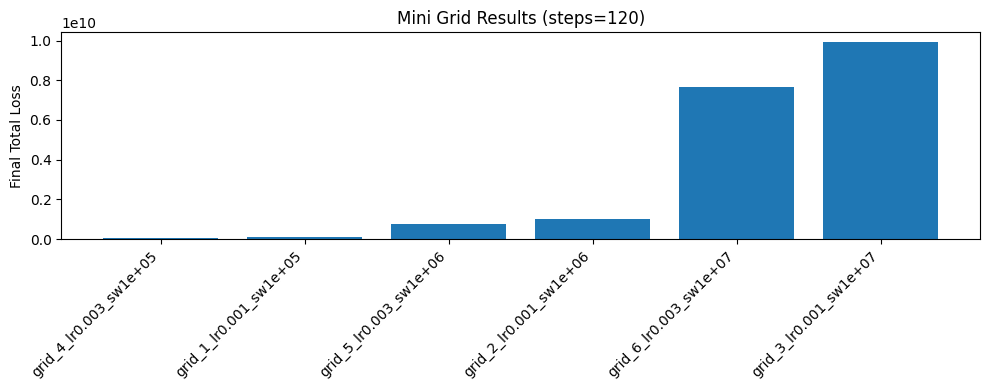

Saved plot: results/mini_grid_loss_comparison.png


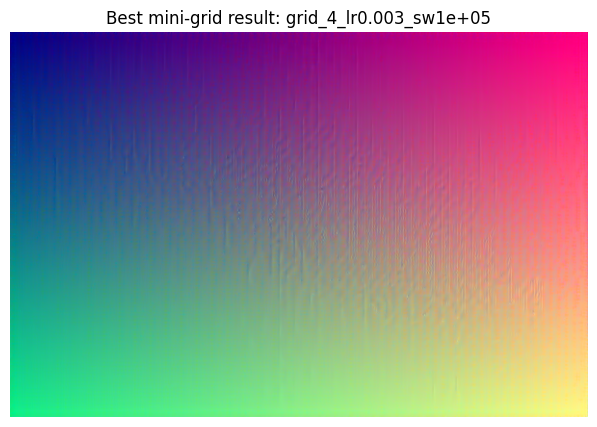

1. timestamp=2026-04-23T14:25:26, run_name=grid_1_lr0.001_sw1e+05, steps=120, lr=0.001, content_weight=1.0, style_weight=100000.0, final_total_loss=99199752.0, elapsed_seconds=154.97846031188965, notes=mini-grid auto run
2. timestamp=2026-04-23T14:28:00, run_name=grid_2_lr0.001_sw1e+06, steps=120, lr=0.001, content_weight=1.0, style_weight=1000000.0, final_total_loss=991983936.0, elapsed_seconds=154.20793223381042, notes=mini-grid auto run
3. timestamp=2026-04-23T14:30:36, run_name=grid_3_lr0.001_sw1e+07, steps=120, lr=0.001, content_weight=1.0, style_weight=10000000.0, final_total_loss=9919816704.0, elapsed_seconds=155.7177541255951, notes=mini-grid auto run
4. timestamp=2026-04-23T14:33:10, run_name=grid_4_lr0.003_sw1e+05, steps=120, lr=0.003, content_weight=1.0, style_weight=100000.0, final_total_loss=76676984.0, elapsed_seconds=153.8684573173523, notes=mini-grid auto run
5. timestamp=2026-04-23T14:35:43, run_name=grid_5_lr0.003_sw1e+06, steps=120, lr=0.003, content_weight=1.0, styl

In [26]:
grid_results = run_experiment_grid(
    steps_per_run=120,
    lrs=(0.001, 0.003),
    style_weights_grid=(1e5, 1e6, 1e7),
    content_w=1.0,
)

show_experiments()
save_experiments_csv('results/style_transfer_experiments.csv')

Running grid_1_lr0.002_sw5e+04 (1/4) ...
Running grid_2_lr0.002_sw1e+05 (2/4) ...
Running grid_3_lr0.003_sw5e+04 (3/4) ...
Running grid_4_lr0.003_sw1e+05 (4/4) ...
Top runs by final loss:
{'run_name': 'grid_3_lr0.003_sw5e+04', 'steps': 120, 'lr': 0.003, 'content_weight': 1.0, 'style_weight': 50000.0, 'final_total_loss': 29303708.0, 'elapsed_seconds': 250.79628539085388}
{'run_name': 'grid_1_lr0.002_sw5e+04', 'steps': 120, 'lr': 0.002, 'content_weight': 1.0, 'style_weight': 50000.0, 'final_total_loss': 37537556.0, 'elapsed_seconds': 248.71417760849}
{'run_name': 'grid_4_lr0.003_sw1e+05', 'steps': 120, 'lr': 0.003, 'content_weight': 1.0, 'style_weight': 100000.0, 'final_total_loss': 58607668.0, 'elapsed_seconds': 252.79154205322266}
Saved 10 rows to results/style_transfer_experiments.csv


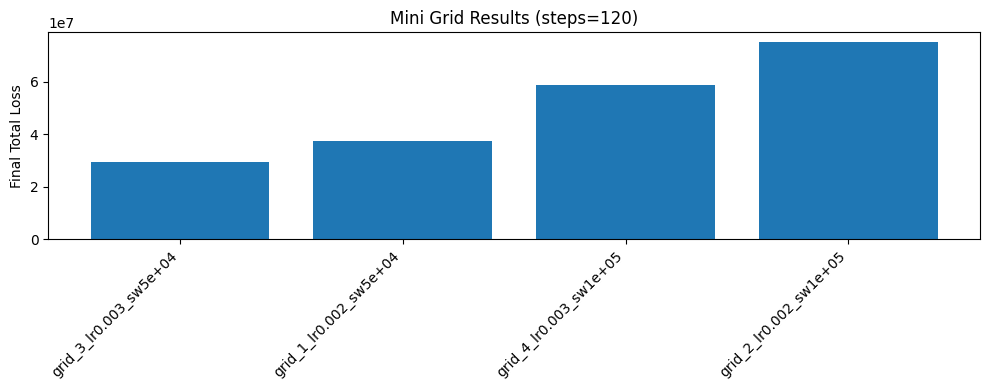

Saved plot: results/mini_grid_loss_comparison.png


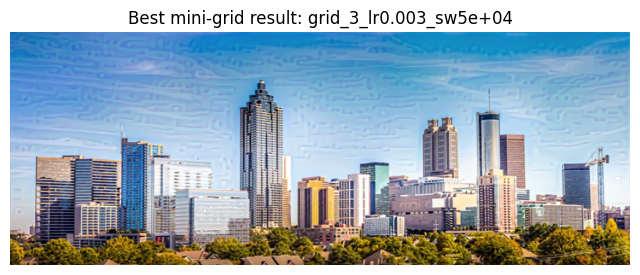

Focused sweep complete.
Best focused config: {'run_name': 'grid_3_lr0.003_sw5e+04', 'steps': 120, 'lr': 0.003, 'content_weight': 1.0, 'style_weight': 50000.0, 'final_total_loss': 29303708.0, 'elapsed_seconds': 250.79628539085388}
1. timestamp=2026-04-23T14:25:26, run_name=grid_1_lr0.001_sw1e+05, steps=120, lr=0.001, content_weight=1.0, style_weight=100000.0, final_total_loss=99199752.0, elapsed_seconds=154.97846031188965, notes=mini-grid auto run
2. timestamp=2026-04-23T14:28:00, run_name=grid_2_lr0.001_sw1e+06, steps=120, lr=0.001, content_weight=1.0, style_weight=1000000.0, final_total_loss=991983936.0, elapsed_seconds=154.20793223381042, notes=mini-grid auto run
3. timestamp=2026-04-23T14:30:36, run_name=grid_3_lr0.001_sw1e+07, steps=120, lr=0.001, content_weight=1.0, style_weight=10000000.0, final_total_loss=9919816704.0, elapsed_seconds=155.7177541255951, notes=mini-grid auto run
4. timestamp=2026-04-23T14:33:10, run_name=grid_4_lr0.003_sw1e+05, steps=120, lr=0.003, content_weight

In [31]:
focused_results = run_experiment_grid(
    steps_per_run=120,
    lrs=(0.002, 0.003),
    style_weights_grid=(5e4, 1e5),
    content_w=1.0,
)

print('Focused sweep complete.')
print('Best focused config:', focused_results[0])
show_experiments()
save_experiments_csv('results/style_transfer_experiments.csv')

Running long_lr0.003_sw5e4_s600 ...
step=150/600, total_loss=24682722.0000
step=300/600, total_loss=12726909.0000
step=450/600, total_loss=8117657.0000
step=600/600, total_loss=5862985.0000


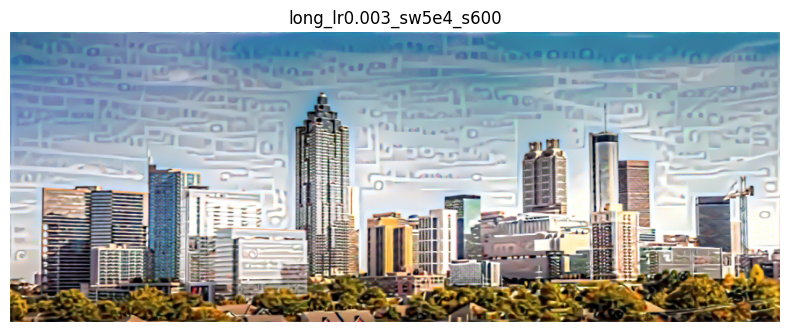

Running long_lr0.003_sw1e5_s600 ...
step=150/600, total_loss=49366148.0000
step=300/600, total_loss=25453060.0000
step=450/600, total_loss=16237240.0000
step=600/600, total_loss=11726522.0000


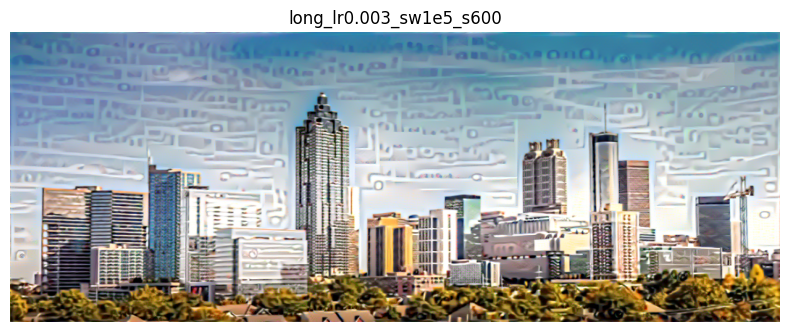

Long-run results (best first):
{'run_name': 'long_lr0.003_sw5e4_s600', 'steps': 600, 'lr': 0.003, 'content_weight': 1.0, 'style_weight': 50000.0, 'final_total_loss': 5862985.0, 'elapsed_seconds': 1282.2066359519958, 'image_path': 'results/long_lr0.003_sw5e4_s600.png'}
{'run_name': 'long_lr0.003_sw1e5_s600', 'steps': 600, 'lr': 0.003, 'content_weight': 1.0, 'style_weight': 100000.0, 'final_total_loss': 11726522.0, 'elapsed_seconds': 2431.6962978839874, 'image_path': 'results/long_lr0.003_sw1e5_s600.png'}
1. timestamp=2026-04-23T14:25:26, run_name=grid_1_lr0.001_sw1e+05, steps=120, lr=0.001, content_weight=1.0, style_weight=100000.0, final_total_loss=99199752.0, elapsed_seconds=154.97846031188965, notes=mini-grid auto run
2. timestamp=2026-04-23T14:28:00, run_name=grid_2_lr0.001_sw1e+06, steps=120, lr=0.001, content_weight=1.0, style_weight=1000000.0, final_total_loss=991983936.0, elapsed_seconds=154.20793223381042, notes=mini-grid auto run
3. timestamp=2026-04-23T14:30:36, run_name=grid

In [32]:
import os

os.makedirs('results', exist_ok=True)

long_run_settings = [
    ('long_lr0.003_sw5e4_s600', 600, 0.003, 1.0, 5e4),
    ('long_lr0.003_sw1e5_s600', 600, 0.003, 1.0, 1e5),
]

long_run_results = []

for run_name, steps_run, lr, c_w, s_w in long_run_settings:
    print(f'Running {run_name} ...')
    out_img, out_loss, out_elapsed = run_style_transfer_once(
        steps_run=steps_run,
        lr=lr,
        c_weight=c_w,
        s_weight=s_w,
        show_progress=True,
    )

    # Log for CSV/report table.
    log_experiment(
        run_name=run_name,
        steps=steps_run,
        lr=lr,
        content_w=c_w,
        style_w=s_w,
        final_loss=out_loss,
        elapsed_s=out_elapsed,
        notes='long-run comparison'
    )

    # Save final image for report.
    img_path = f'results/{run_name}.png'
    plt.figure(figsize=(8, 5))
    plt.imshow(im_convert(out_img))
    plt.axis('off')
    plt.title(run_name)
    plt.tight_layout()
    plt.savefig(img_path, dpi=180)
    plt.show()

    long_run_results.append({
        'run_name': run_name,
        'steps': steps_run,
        'lr': lr,
        'content_weight': c_w,
        'style_weight': s_w,
        'final_total_loss': out_loss,
        'elapsed_seconds': out_elapsed,
        'image_path': img_path,
    })

long_run_results = sorted(long_run_results, key=lambda x: x['final_total_loss'])
print('Long-run results (best first):')
for row in long_run_results:
    print(row)

show_experiments()
save_experiments_csv('results/style_transfer_experiments.csv')